#Tesla EV Analytics & Predictive ML Pipeline

##Objective: Developed an end-to-end machine learning pipeline utilizing 10 years of global Tesla data (2015–2025) to automate data cleaning, engineer domain-specific features, optimize price regression models, and forecast future delivery trends.

# Import Libraries

In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from statsmodels.tsa.arima.model import ARIMA

print("All libraries loaded Successfully")

All libraries loaded Successfully


#Data Loading and Shape Inspection

In [235]:
# Load the dataset
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print("Dataset loaded Successfully")


print("\nDataset shape")
print(df.shape)

print("\nDataset columns")
print(df.columns)

Dataset loaded Successfully

Dataset shape
(2640, 12)

Dataset columns
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [236]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


#Data Cleaning and Summary Statistics

In [237]:
#Check Null values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [238]:
#Check Duplicate Values
print(df.duplicated().sum())

0


In [239]:
#Dataset Statistical summary
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Date Creation and Time Series Preparation

In [276]:
#Date Creation and Time Series Preparation

df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)


df = df.sort_values('Date')


df = df.reset_index(drop=True)

print("Date column created successfully.\n")

display(
    df[['Date', 'Year', 'Month', 'Estimated_Deliveries']].head()
)

print("\nDate Range:")
print("Start:", df['Date'].min())
print("End  :", df['Date'].max())

Date column created successfully.



,Date,Year,Month,Estimated_Deliveries
0,2015-01-01,2015,1,12446
1,2015-01-01,2015,1,10348
2,2015-01-01,2015,1,10835
3,2015-01-01,2015,1,12170
4,2015-01-01,2015,1,7597



Date Range:
Start: 2015-01-01 00:00:00
End  : 2025-12-01 00:00:00


# Exploratory Data Analysis

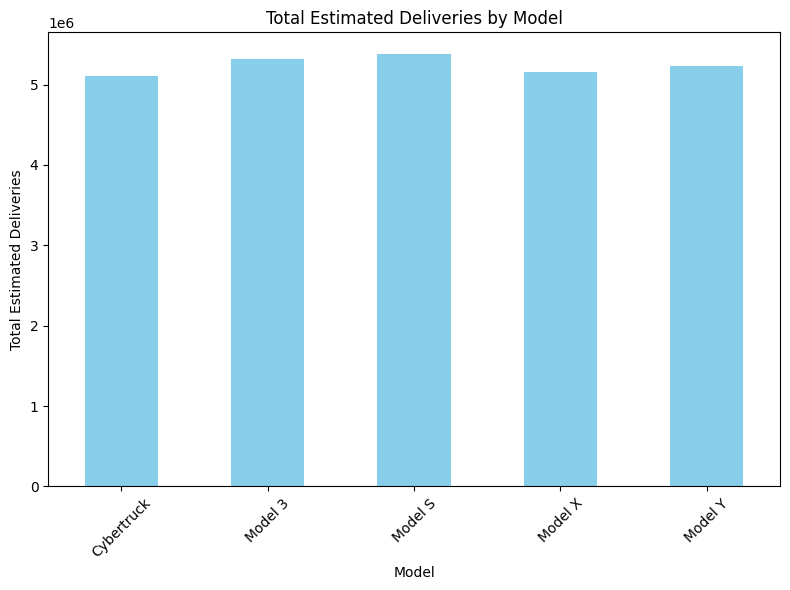

In [241]:
#Total Estimated Deliveries by Model

plt.figure(figsize=(8, 6))
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum()
model_deliveries.plot(kind='bar', color='skyblue')

plt.title('Total Estimated Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

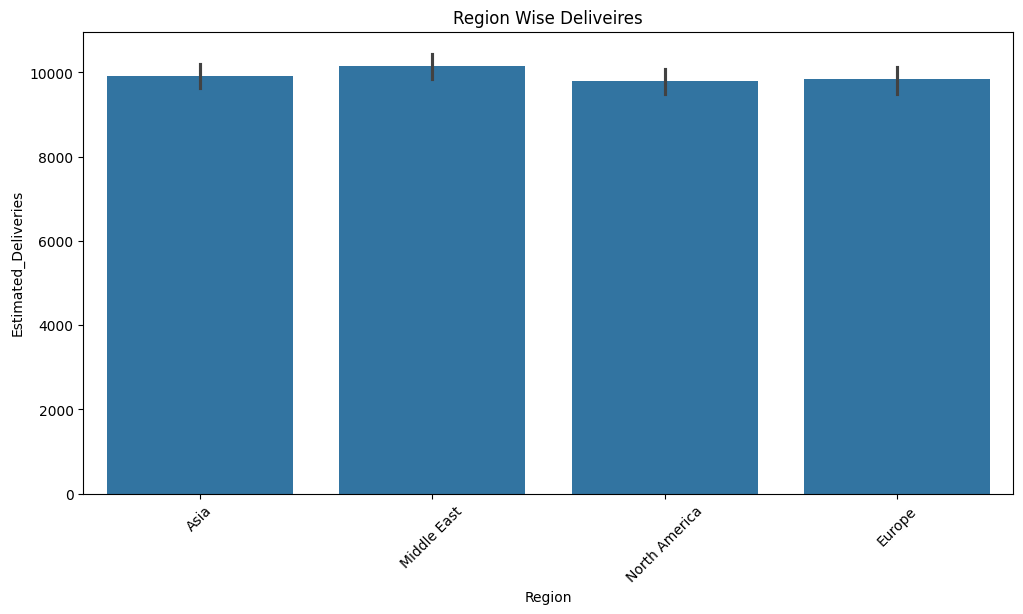

In [242]:
#Region Wise Deliveries

plt.figure(figsize=(12, 6))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.xticks(rotation=45)
plt.title("Region Wise Deliveires")
plt.show()

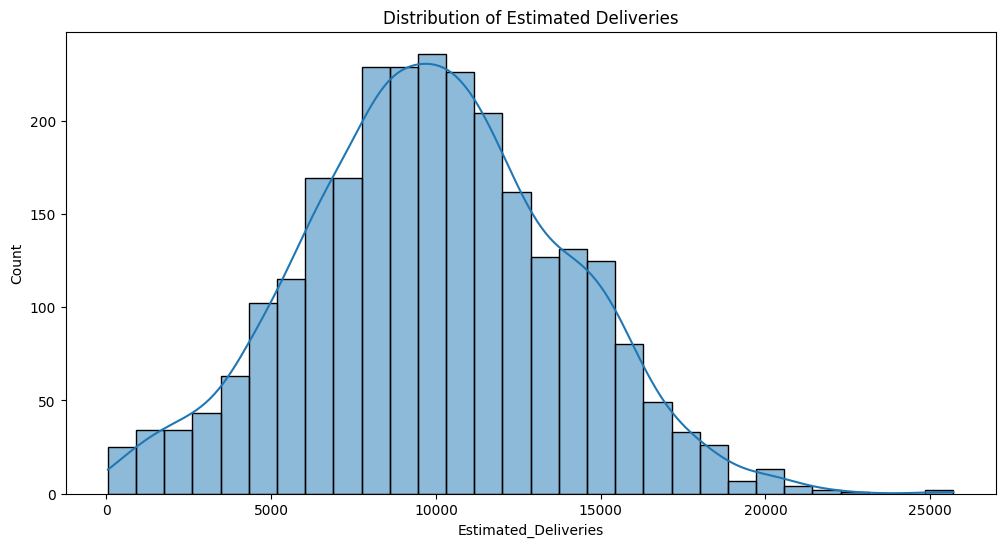

In [243]:
#Distribution Plot

plt.figure(figsize=(12, 6))

sns.histplot(
    df['Estimated_Deliveries'],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")

plt.show()

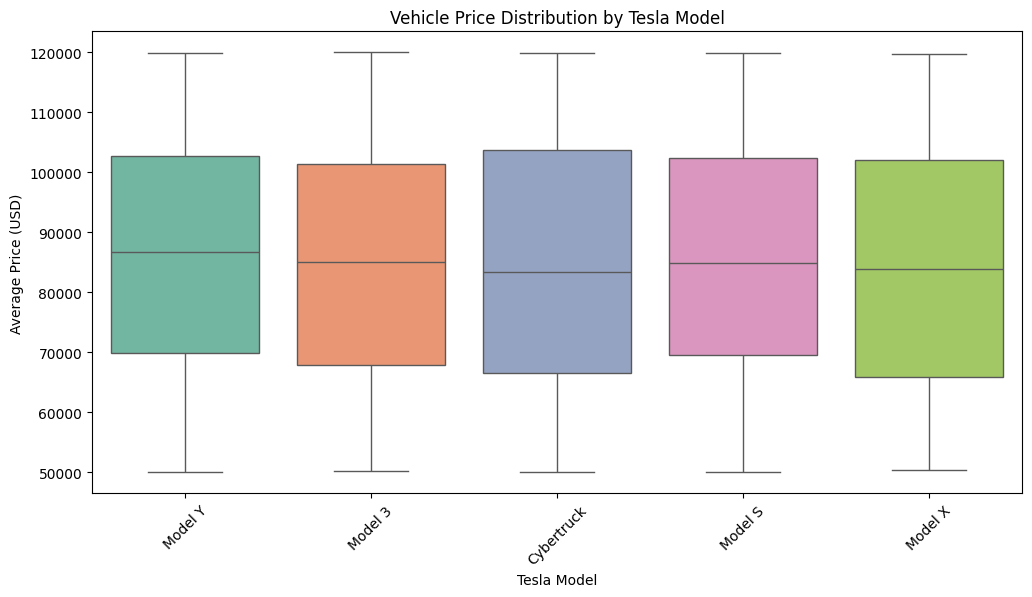

In [244]:
#Vehicle Price Distribution by Tesla Model

plt.figure(figsize=(12, 6))
sns.boxplot(data=df,
            x='Model',
            y='Avg_Price_USD',
            hue='Model',
            palette='Set2')

plt.title('Vehicle Price Distribution by Tesla Model')
plt.xlabel('Tesla Model')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)

plt.show()

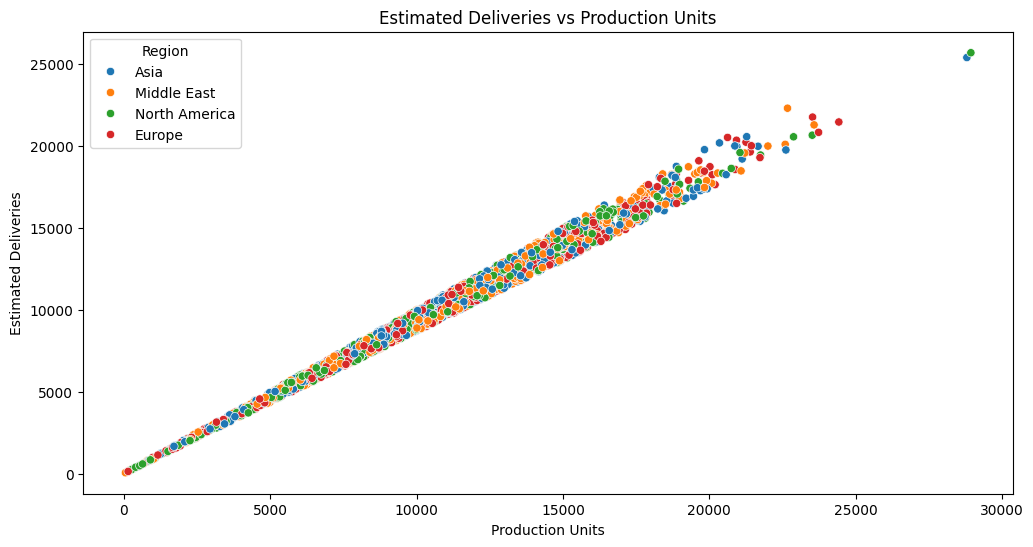

In [245]:
#Estimated Deliveries vs Production Units

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df,
                x='Production_Units',
                y='Estimated_Deliveries',
                hue='Region')

plt.title('Estimated Deliveries vs Production Units')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')

plt.show()

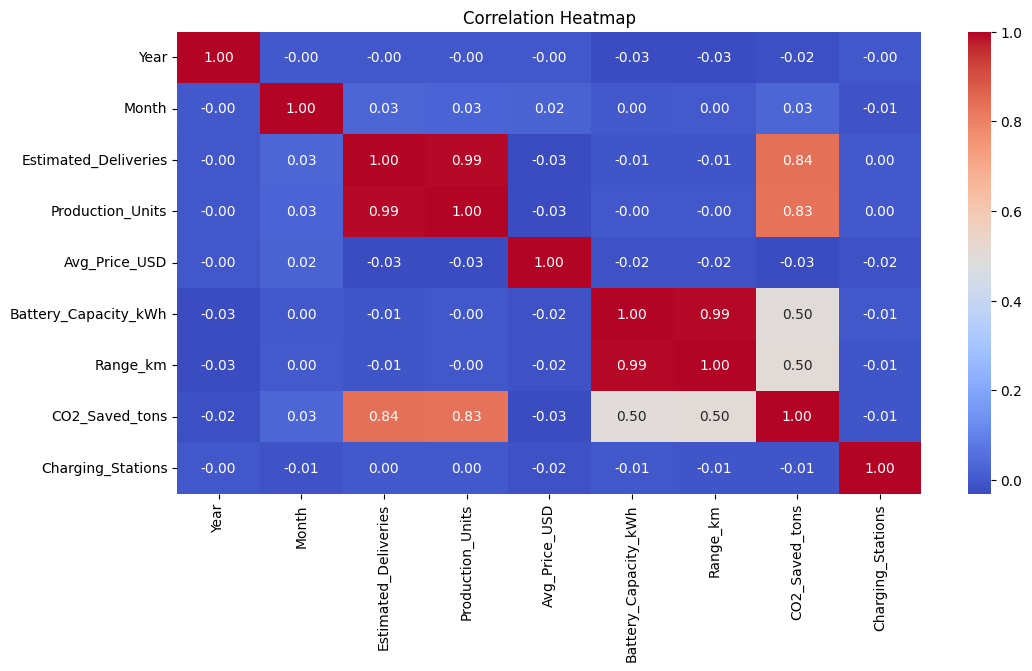

In [246]:
#Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"

)

plt.title("Correlation Heatmap")

plt.show()

Number of Outliers: 12


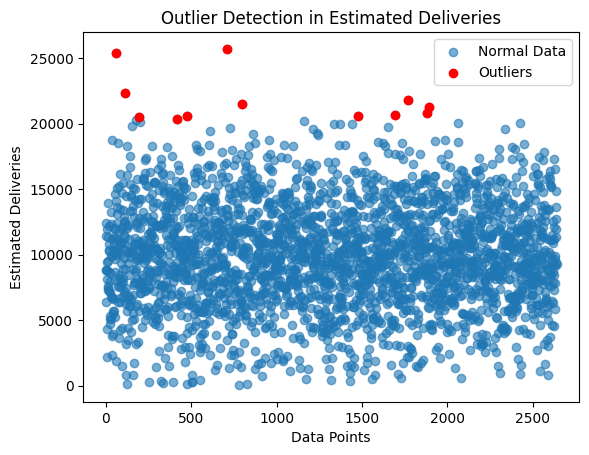

In [247]:
#Outlier Detection in Estimated Deliveries

q1, q3 = df["Estimated_Deliveries"].quantile([0.25, 0.75])
iqr = q3 - q1

is_inside = df["Estimated_Deliveries"].between(q1 - 1.5 * iqr,
                                               q3 + 1.5 * iqr)
outliers = df[~is_inside]

print(f"Number of Outliers: {len(outliers)}")

plt.scatter(df.index, df["Estimated_Deliveries"],
            label="Normal Data", alpha=0.6)
plt.scatter(
    outliers.index, outliers["Estimated_Deliveries"],
    color="red", label="Outliers"
)

plt.title("Outlier Detection in Estimated Deliveries")
plt.xlabel("Data Points")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.show()

# Feature Engineering

In [248]:
#Feature Engineering

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Region'] = le.fit_transform(df['Region'])
df['Model'] = le.fit_transform(df['Model'])
df['Source_Type'] = le.fit_transform(df['Source_Type'])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,2015-01-01
1,2015,1,2,1,11446,12752,89289.40,100,588,1009.54,0,8925,2015-01-01
2,2015,1,2,0,8803,9344,102888.58,60,336,443.67,1,3923,2015-01-01
3,2015,1,3,0,6367,6802,104962.32,82,459,438.37,0,9170,2015-01-01
4,2015,1,0,1,8795,9165,87988.73,82,456,601.58,2,12626,2015-01-01


#Lag and Rolling Features Generation

In [249]:

df["Lag_1"] = df["Estimated_Deliveries"].shift(1)
df["Lag_2"] = df["Estimated_Deliveries"].shift(2)


df["Rolling_Mean_3"] = df["Estimated_Deliveries"].shift(1).rolling(3).mean()
df["Rolling_STD_3"] = df["Estimated_Deliveries"].shift(1).rolling(3).std()


df = df.bfill()

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Lag_1,Lag_2,Rolling_Mean_3,Rolling_STD_3
0,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,2015-01-01,12446.0,12446.0,10898.333333,1882.237056
1,2015,1,2,1,11446,12752,89289.40,100,588,1009.54,0,8925,2015-01-01,12446.0,12446.0,10898.333333,1882.237056
2,2015,1,2,0,8803,9344,102888.58,60,336,443.67,1,3923,2015-01-01,11446.0,12446.0,10898.333333,1882.237056
3,2015,1,3,0,6367,6802,104962.32,82,459,438.37,0,9170,2015-01-01,8803.0,11446.0,10898.333333,1882.237056
4,2015,1,0,1,8795,9165,87988.73,82,456,601.58,2,12626,2015-01-01,6367.0,8803.0,8872.000000,2540.202945


In [250]:
x = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

In [251]:
# Quarter Feature
df['Quarter'] = df['Month'].apply(
    lambda x: (x - 1)//3 + 1
)

# Month Start Indicator
df['Month_Start'] = 1

print("Feature Engineering Completed.\n")

display(
    df[
        [
            'Date',
            'Year',
            'Month',
            'Quarter',
            'Estimated_Deliveries'
        ]
    ].head()
)

Feature Engineering Completed.



,Date,Year,Month,Quarter,Estimated_Deliveries
0,2015-01-01,2015,1,1,12446
1,2015-01-01,2015,1,1,11446
2,2015-01-01,2015,1,1,8803
3,2015-01-01,2015,1,1,6367
4,2015-01-01,2015,1,1,8795


# Encoding Techniques

In [252]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Region',
        'Model',
        'Source_Type'
    ],
    drop_first=True
)

print("Original Shape :", df.shape)
print("Encoded Shape  :", df_encoded.shape)

print("\nEncoded Columns Created Successfully.\n")

display(df_encoded.head())

Original Shape : (2640, 19)
Encoded Shape  : (2640, 25)

Encoded Columns Created Successfully.



,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,...,Month_Start,Region_1,Region_2,Region_3,Model_1,Model_2,Model_3,Model_4,Source_Type_1,Source_Type_2
0,2015,1,12446,13885,55183.13,60,340,634.75,4390,2015-01-01,...,1,False,False,False,False,False,False,True,False,True
1,2015,1,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01,...,1,False,True,False,True,False,False,False,False,False
2,2015,1,8803,9344,102888.58,60,336,443.67,3923,2015-01-01,...,1,False,True,False,False,False,False,False,True,False
3,2015,1,6367,6802,104962.32,82,459,438.37,9170,2015-01-01,...,1,False,False,True,False,False,False,False,False,False
4,2015,1,8795,9165,87988.73,82,456,601.58,12626,2015-01-01,...,1,False,False,False,True,False,False,False,False,True


# Feature Scaling

In [253]:
#Features and Target Variable

x = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

# Chronological Train-Test Split

In [254]:
#Train_Test_Split the data

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2112, 18)
Testing Shape: (528, 18)


In [255]:
X_train_numeric = X_train.drop('Date', axis=1)
X_test_numeric = X_test.drop('Date', axis=1)

# Linear Regression Model

In [256]:
#Linear Regression Model

lr_model = LinearRegression()
lr_model.fit(X_train_numeric, y_train)
lr_pred = lr_model.predict(X_test_numeric)

print("linear Regression Model Trained")

linear Regression Model Trained


In [257]:
#Linear Regression Evalutiona

print("Linear Regression Evalutiona")

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))


Linear Regression Evalutiona
MAE: 312.46458902476763
RMSE: 381.472856730403
R2 Score: 0.9902873966626082


#Ridge Regression Model

In [258]:
#Ridge Regression Model

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_numeric, y_train)

ridge_pred = ridge_model.predict(X_test_numeric)

In [259]:
#Ridge Regression Evaluation

print("Ridge Regression Evaluation")

print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2 Score:", r2_score(y_test, ridge_pred))

Ridge Regression Evaluation
MAE: 312.4643590577366
RMSE: 381.4739684501185
R2 Score: 0.9902873400519836


#Lasso Regression Model

In [260]:
#Lasso Regression Model

from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train_numeric, y_train)

lasso_pred = lasso_model.predict(X_test_numeric)

In [261]:
#Lasso Regression Evaluation

print("Lasso Regression Evaluation")

print("MAE:", mean_absolute_error(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R2 Score:", r2_score(y_test, lasso_pred))

Lasso Regression Evaluation
MAE: 312.3820094585607
RMSE: 381.5585833718285
R2 Score: 0.9902830308347107


#Model Comparison of 3 models

Best Model: Linear Regression
Best R2 Score: 0.990287


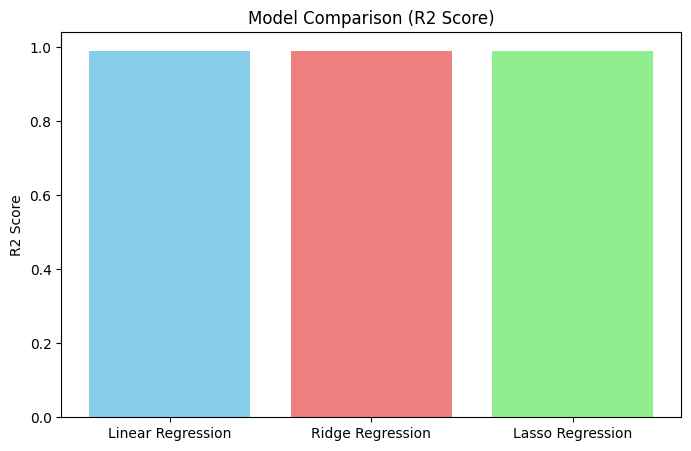

In [277]:
#Model Comparison of 3 models


lr_r2 = r2_score(y_test, lr_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "R2 Score": [lr_r2, ridge_r2, lasso_r2]
})

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["R2 Score"]
)
plt.bar(comparison_df["Model"], comparison_df["R2 Score"], color=['skyblue',
                                                                  'lightcoral',
                                                                  'lightgreen'])
plt.ylabel("R2 Score")
plt.title("Model Comparison (R2 Score)")


best_model = comparison_df.loc[
    comparison_df["R2 Score"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Best R2 Score:", round(best_model["R2 Score"],6))

plt.show()

# Cross Validation using TimeSeriesSplit

In [278]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

tscv = TimeSeriesSplit(n_splits=5)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(x.drop('Date', axis=1))

ridge_cv_scores = cross_val_score(
    Ridge(alpha=1.0),
    X_scaled,
    y,
    cv=tscv,
    scoring='r2'
)

print("Time Series Cross Validation R² Scores:\n")
print(ridge_cv_scores)

print("\nMean R² Score:")
print(round(ridge_cv_scores.mean(), 4))

print("\nStandard Deviation:")
print(round(ridge_cv_scores.std(), 4))

Time Series Cross Validation R² Scores:

[0.99103443 0.99039276 0.99113649 0.99042898 0.98864225]

Mean R² Score:
0.9903

Standard Deviation:
0.0009


# Hyperparameter Tuning (Ridge Regression)

In [264]:
#Hyperparameter Tuning

param_grid = {
    'alpha': [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2'
)

grid_search.fit(
    X_scaled,
    y
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R²:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'alpha': 0.1}

Best Cross Validation R²:
0.9903


# Time Series Components

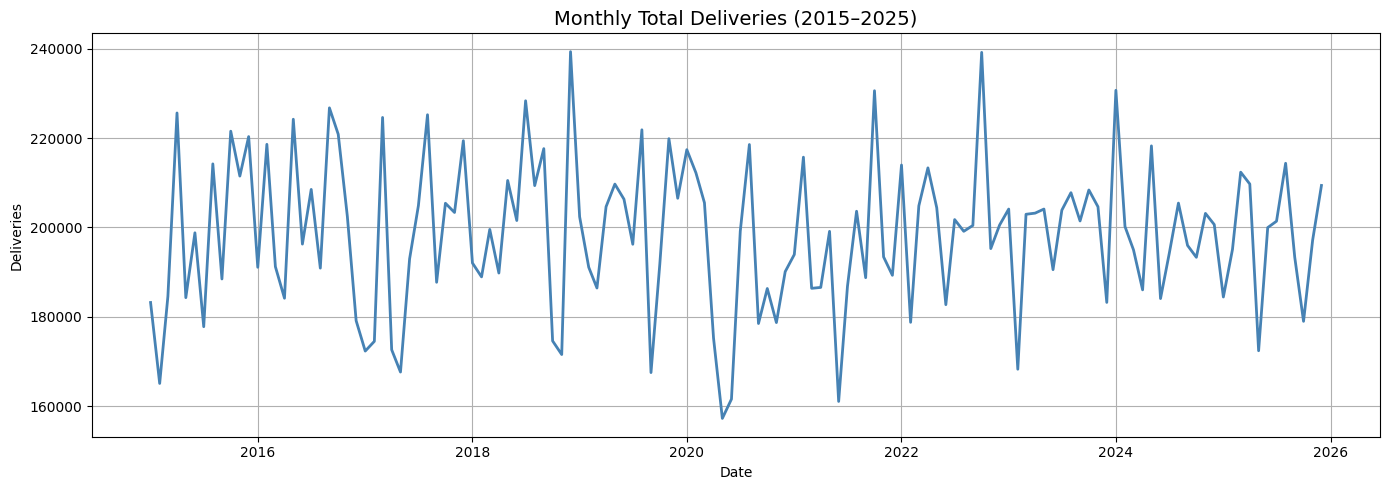

In [265]:
ts = df.groupby(["Year", "Month"])["Estimated_Deliveries"].sum().reset_index()
ts["Date"] = pd.to_datetime(ts[["Year", "Month"]].assign(Day=1))
ts = ts.sort_values("Date")

plt.figure(figsize=(14, 5))
plt.plot(ts["Date"], ts["Estimated_Deliveries"], color="steelblue", lw=2)

plt.title("Monthly Total Deliveries (2015–2025)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.grid(True)
plt.tight_layout()
plt.show()

In [266]:

ts_df = df.groupby("Date")["Estimated_Deliveries"].mean().reset_index()

s = ts_df["Estimated_Deliveries"]
shifted = s.shift(1)

ts_df = ts_df.assign(
    Lag_1=s.shift(1),
    Lag_3=s.shift(3),
    Lag_6=s.shift(6),
    Lag_12=s.shift(12),
    Rolling_Mean_3=shifted.rolling(3).mean(),
    Rolling_Mean_6=shifted.rolling(6).mean(),
    Rolling_Std_3=shifted.rolling(3).std(),
).dropna().reset_index(drop=True)

print(f"Forecasting Dataset Shape:\n{ts_df.shape}")
display(ts_df.head())

Forecasting Dataset Shape:
(120, 9)


,Date,Estimated_Deliveries,Lag_1,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Std_3
0,2016-01-01,9553.45,11016.60,11077.05,8887.95,9159.00,10889.383333,10281.608333,274.366882
1,2016-02-01,10930.00,9553.45,10574.50,10711.15,8252.65,10381.516667,10392.525000,750.422485
2,2016-03-01,9560.40,10930.00,11016.60,9422.40,9228.35,10500.016667,10429.000000,820.893556
3,2016-04-01,9206.70,9560.40,9553.45,11077.05,11281.15,10014.616667,10452.000000,792.752837
4,2016-05-01,11211.00,9206.70,10930.00,10574.50,9213.20,9899.033333,10140.275000,910.189608


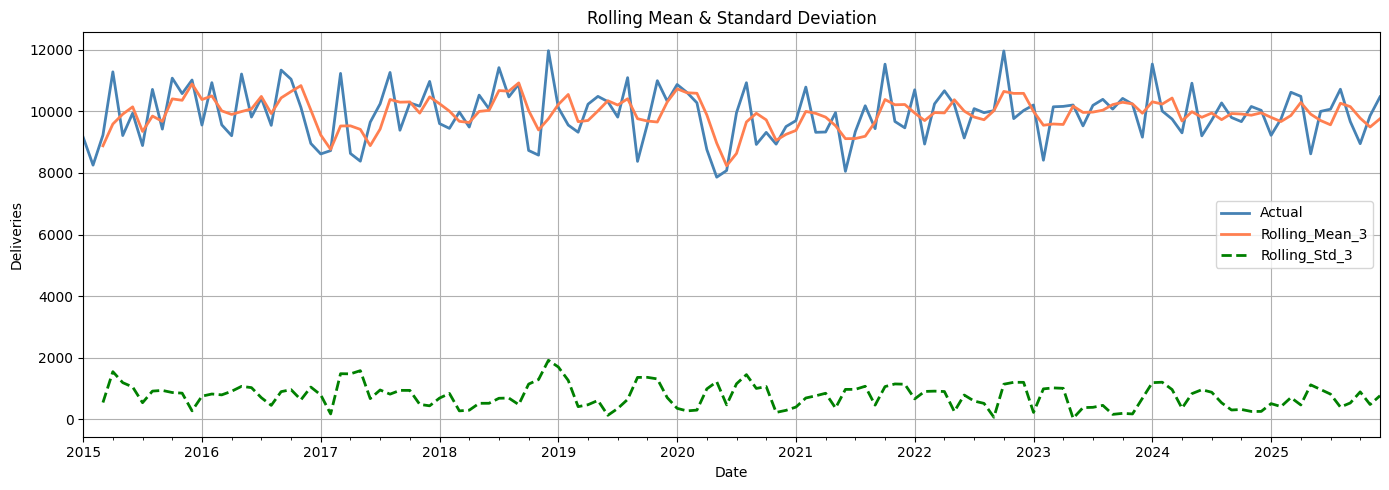

In [267]:
r_df = df.groupby("Date")["Estimated_Deliveries"].mean().rolling(3).agg(["mean", "std"])
r_df.columns = ["Rolling_Mean_3", "Rolling_Std_3"]
r_df["Actual"] = df.groupby("Date")["Estimated_Deliveries"].mean()

r_df[["Actual", "Rolling_Mean_3", "Rolling_Std_3"]].plot(
    figsize=(14, 5),
    color=["steelblue", "coral", "green"],
    style=["-", "-", "--"],
    lw=2,
    grid=True,
    title="Rolling Mean & Standard Deviation",
)

plt.ylabel("Deliveries")
plt.tight_layout()
plt.show()

In [268]:

features = [
    "Lag_1",
    "Lag_3",
    "Lag_6",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_6",
    "Rolling_Std_3",
]
X_forecast = ts_df[features]
y_forecast = ts_df["Estimated_Deliveries"]


split = int(len(ts_df) * 0.8)
X_train_f, X_test_f = X_forecast[:split], X_forecast[split:]
y_train_f, y_test_f = y_forecast[:split], y_forecast[split:]


print(f"Training Samples: {len(X_train_f)} | Train Shape: {X_train_f.shape}")
print(f"Testing Samples : {len(X_test_f)}  | Test Shape : {X_test_f.shape}")

Training Samples: 96 | Train Shape: (96, 7)
Testing Samples : 24  | Test Shape : (24, 7)


In [269]:

forecast_model = Ridge(alpha=1).fit(X_train_f, y_train_f)


forecast_predictions = forecast_model.predict(X_test_f)

print("Forecasting Model Trained Successfully!")

Forecasting Model Trained Successfully!


Forecast Preview:
 2026-01-01    192503.413088
2026-02-01    190435.129208
2026-03-01    198070.502476
2026-04-01    189794.124276
2026-05-01    197737.023790
Freq: MS, dtype: float64


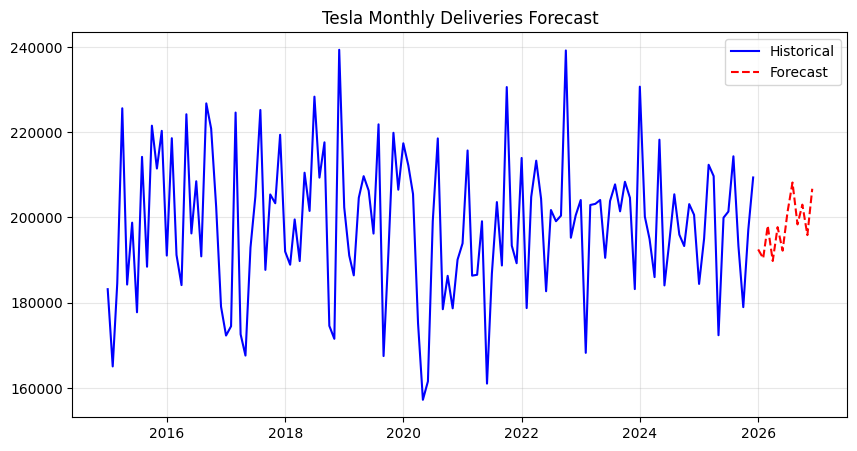

In [270]:
#Forecast Visualization

df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str))
ts = df.set_index("Date").resample("MS")["Estimated_Deliveries"].sum()

forecast = (
    ExponentialSmoothing(ts, trend="add", seasonal="add", seasonal_periods=12)
    .fit()
    .forecast(12)
)
print("Forecast Preview:\n", forecast.head())


plt.figure(figsize=(10, 5))
plt.plot(ts.index, ts, label="Historical", color="blue")
plt.plot(forecast.index, forecast, label="Forecast", color="red", ls="--")
plt.title("Tesla Monthly Deliveries Forecast")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [271]:
#Time series Forecasting

yearly_data = df.groupby("Year")['Estimated_Deliveries'].sum()

yearly_data.index = pd.to_datetime(yearly_data.index, format='%Y')
yearly_data = yearly_data.asfreq('YS')
model = ARIMA(yearly_data, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)

forecast_df = pd.DataFrame({
    'Year': forecast.index.year,
    'Forecasted_Deliveries': forecast.values.astype(int)
})

print(forecast_df)

   Year  Forecasted_Deliveries
0  2026                2366761
1  2027                2367843
2  2028                2367154
3  2029                2367593
4  2030                2367314


In [272]:
forecast_df = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": lr_pred[:20]
})

forecast_df

,Actual,Predicted
0,11264,11713.130096
1,5052,5348.799683
2,12370,12778.718243
3,10739,10657.488985
4,3988,3763.628740
5,11163,10735.623080
6,10936,11299.429962
7,2904,2477.716047
8,12876,13409.868241
9,9755,10138.147697


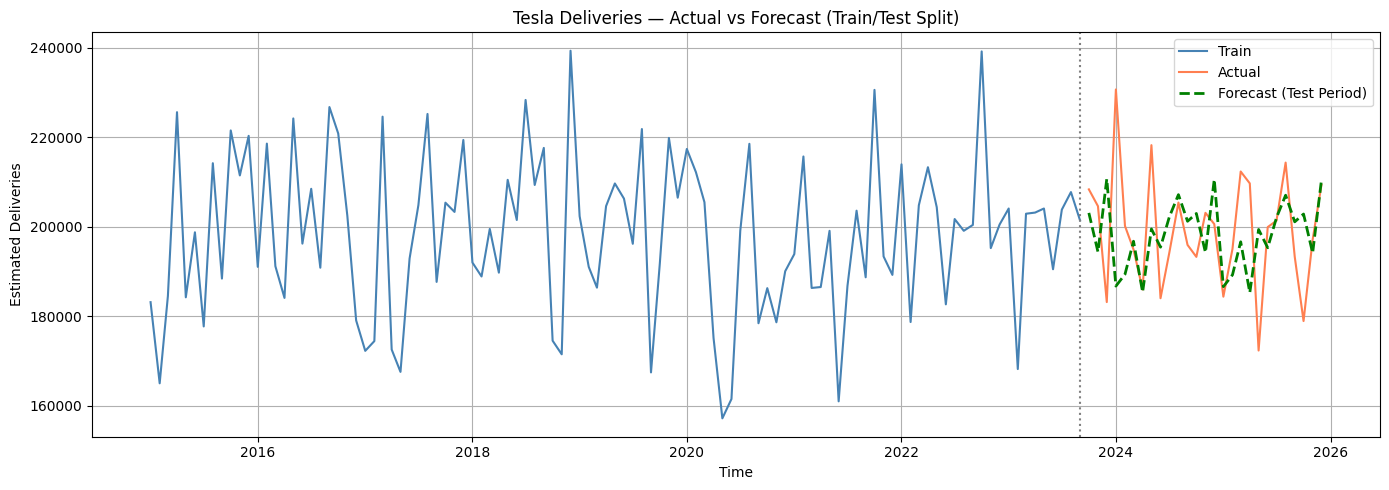

In [273]:
#Tesla Deliveries — Actual vs Forecast
from statsmodels.tsa.holtwinters import ExponentialSmoothing

plt.figure(figsize=(14,5))


train_size = int(len(ts) * 0.8)
ts_train = ts.iloc[:train_size]
ts_test = ts.iloc[train_size:]


model_es_train = ExponentialSmoothing(ts_train, trend="add", seasonal="add", seasonal_periods=12).fit()
forecast_predictions_test_period = model_es_train.forecast(len(ts_test))


plt.plot(
    ts_train.index,
    ts_train.values,
    label='Train',
    color='steelblue'
)

plt.plot(
    ts_test.index,
    ts_test.values,
    label='Actual',
    color='coral'
)


plt.plot(
    forecast_predictions_test_period.index,
    forecast_predictions_test_period.values,
    label='Forecast (Test Period)',
    color='green',
    linestyle='--',
    linewidth=2
)


plt.axvline(
    x=ts_train.index[-1],
    color='gray',
    linestyle=':',
    linewidth=1.5
)

plt.title('Tesla Deliveries — Actual vs Forecast (Train/Test Split)')

plt.xlabel('Time')
plt.ylabel('Estimated Deliveries')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()